In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from pathlib import Path

%matplotlib inline

In [2]:
output_file = "../data/02_processed/CICIDS2018_processed.csv"

csv_files = [
    "../data/01_raw/CIC-IDS2018/CSV/Tuesday-20-02-2018_TrafficForML_CICFlowMeter.csv",
    "../data/01_raw/CIC-IDS2018/CSV/Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv",
    "../data/01_raw/CIC-IDS2018/CSV/Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv",
    "../data/01_raw/CIC-IDS2018/CSV/Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv",
    "../data/01_raw/CIC-IDS2018/CSV/Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv",
    "../data/01_raw/CIC-IDS2018/CSV/Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv",
    "../data/01_raw/CIC-IDS2018/CSV/Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv",
    "../data/01_raw/CIC-IDS2018/CSV/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv",
    "../data/01_raw/CIC-IDS2018/CSV/Friday-16-02-2018_TrafficForML_CICFlowMeter.csv",
    "../data/01_raw/CIC-IDS2018/CSV/Friday-23-02-2018_TrafficForML_CICFlowMeter.csv",
]

# 칼럼명
RENAME = {
    "Flow Duration": "Flow duration",
    "Tot Fwd Pkts": "total Fwd packets",
    "Tot Bwd Pkts": "total Bwd packets",
    "TotLen Fwd Pkts": "total Length of Fwd Packet",
    "TotLen Bwd Pkts": "total Length of Bwd Packet",
    "Fwd Pkt Len Max": "Fwd Packet Length Max",
    "Fwd Pkt Len Min": "Fwd Packet Length Min",
    "Fwd Pkt Len Mean": "Fwd Packet Length Mean",
    "Fwd Pkt Len Std": "Fwd Packet Length Std",
    "Bwd Pkt Len Max": "Bwd Packet Length Max",
    "Bwd Pkt Len Min": "Bwd Packet Length Min",
    "Bwd Pkt Len Mean": "Bwd Packet Length Mean",
    "Bwd Pkt Len Std": "Bwd Packet Length Std",
    "Flow Byts/s": "Flow Bytes/s",
    "Flow Pkts/s": "Flow Packets/s",
    "Flow IAT Mean": "Flow IAT Mean",
    "Flow IAT Std": "Flow IAT Std",
    "Flow IAT Max": "Flow IAT Max",
    "Flow IAT Min": "Flow IAT Min",
    "Fwd IAT Tot": "Fwd IAT Total",
    "Fwd IAT Mean": "Fwd IAT Mean",
    "Fwd IAT Std": "Fwd IAT Std",
    "Fwd IAT Max": "Fwd IAT Max",
    "Fwd IAT Min": "Fwd IAT Min",
    "Bwd IAT Tot": "Bwd IAT Total",
    "Bwd IAT Mean": "Bwd IAT Mean",
    "Bwd IAT Std": "Bwd IAT Std",
    "Bwd IAT Max": "Bwd IAT Max",
    "Bwd IAT Min": "Bwd IAT Min",
    "Fwd PSH Flags": "Fwd PSH Flags",
    "Bwd PSH Flags": "Bwd PSH Flags",
    "Fwd URG Flags": "Fwd URG Flags",
    "Bwd URG Flags": "Bwd URG Flags",
    "Fwd Header Len": "Fwd Header Length",
    "Bwd Header Len": "Bwd Header Length",
    "Fwd Pkts/s": "Fwd Packets/s",
    "Bwd Pkts/s": "Bwd Packets/s",
    "Pkt Len Min": "Packet Length Min",
    "Pkt Len Max": "Packet Length Max",
    "Pkt Len Mean": "Packet Length Mean",
    "Pkt Len Std": "Packet Length Std",
    "Pkt Len Var": "Packet Length Variance",
    "FIN Flag Cnt": "FIN Flag Count",
    "SYN Flag Cnt": "SYN Flag Count",
    "RST Flag Cnt": "RST Flag Count",
    "PSH Flag Cnt": "PSH Flag Count",
    "ACK Flag Cnt": "ACK Flag Count",
    "URG Flag Cnt": "URG Flag Count",
    "ECE Flag Cnt": "ECE Flag Count",
    "Down/Up Ratio": "Down/Up Ratio",
    "Pkt Size Avg": "Average Packet Size",
    "Fwd Seg Size Avg": "Fwd Segment Size Avg",
    "Bwd Seg Size Avg": "Bwd Segment Size Avg",
    "Fwd Byts/b Avg": "Fwd Bytes/Bulk Avg",
    "Fwd Pkts/b Avg": "Fwd Packet/Bulk Avg",
    "Fwd Blk Rate Avg": "Fwd Bulk Rate Avg",
    "Bwd Byts/b Avg": "Bwd Bytes/Bulk Avg",
    "Bwd Pkts/b Avg": "Bwd Packet/Bulk Avg",
    "Bwd Blk Rate Avg": "Bwd Bulk Rate Avg",
    "Subflow Fwd Pkts": "Subflow Fwd Packets",
    "Subflow Fwd Byts": "Subflow Fwd Bytes",
    "Subflow Bwd Pkts": "Subflow Bwd Packets",
    "Subflow Bwd Byts": "Subflow Bwd Bytes",
    "Init Fwd Win Byts": "Fwd Init Win bytes",
    "Init Bwd Win Byts": "Bwd Init Win bytes",
    "Fwd Act Data Pkts": "Fwd Active Data Packets",
    "Fwd Seg Size Min": "Fwd Segment Size Min",
    "Active Mean": "Active Mean",
    "Active Std": "Active Std",
    "Active Max": "Active Max",
    "Active Min": "Active Min",
    "Idle Mean": "Idle Mean",
    "Idle Std": "Idle Std",
    "Idle Max": "Idle Max",
    "Idle Min": "Idle Min",
}

# 라벨명
LABEL = {
    "Benign": "BENIGN",
    "Bot": "Bot",
    "DDOS attack-HOIC": "DDoS",
    "DDOS attack-LOIC-UDP": "DDoS",
    "DDoS attacks-LOIC-HTTP": "DDoS",
    "DoS attacks-GoldenEye": "DoS GoldenEye",
    "DoS attacks-Hulk": "DoS Hulk",
    "DoS attacks-SlowHTTPTest": "DoS Slowhttptest",
    "DoS attacks-Slowloris": "DoS Slowloris",
    "FTP-BruteForce": "FTP-Patator",
    "SSH-Bruteforce": "SSH-Patator",
    "Brute Force -Web": "Web Attack - Brute Force",
    "Brute Force -XSS": "Web Attack - XSS",
    "SQL Injection": "Web Attack - Sql Injection",
    "Infilteration": "Infiltration",
}

# 버리는 것
DROP = [
    "Flow ID",
    "Src IP",
    "Src Port",
    "Dst IP",
    "Dst Port",
    "Protocol",
    "Timestamp"
]

In [3]:
df_list = []

for f in csv_files:
    print(f"Loading {Path(f).name} ...")
    tmp = pd.read_csv(f, low_memory=False)
    tmp.columns = tmp.columns.str.strip()

    tmp.rename(columns=RENAME, inplace=True)

    drop_col = [c for c in DROP if c in tmp.columns]
    if drop_col:
        tmp.drop(columns=drop_col, inplace=True, errors="ignore")

    tmp.replace([np.inf, -np.inf], np.nan, inplace=True)
    tmp.dropna(inplace=True)
    tmp.drop_duplicates(inplace=True)

    tmp["Label"]=tmp["Label"].astype(str).str.strip().map(LABEL)
    tmp.dropna(subset=["Label"], inplace=True)

    tmp.reset_index(drop=True, inplace=True)
    print(f"shape: {tmp.shape}, labels: {tmp.Label.unique()}")
    df_list.append(tmp)
    del tmp
    gc.collect()

Loading Tuesday-20-02-2018_TrafficForML_CICFlowMeter.csv ...
shape: (5435775, 77), labels: ['BENIGN' 'DDoS']
Loading Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv ...
shape: (619346, 77), labels: ['BENIGN' 'FTP-Patator' 'SSH-Patator']
Loading Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv ...
shape: (561396, 77), labels: ['BENIGN' 'DDoS']
Loading Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv ...
shape: (458296, 77), labels: ['BENIGN' 'Infiltration']
Loading Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv ...
shape: (249270, 77), labels: ['BENIGN' 'Infiltration']
Loading Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv ...
shape: (794812, 77), labels: ['BENIGN' 'DoS GoldenEye' 'DoS Slowloris']
Loading Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv ...
shape: (830224, 77), labels: ['BENIGN' 'Web Attack - Brute Force' 'Web Attack - XSS'
 'Web Attack - Sql Injection']
Loading Friday-02-03-2018_TrafficForML_CICFlowMeter.csv ...
shape: (771587, 77), labels: ['BENIGN' 'Bot

In [4]:
df = pd.concat(df_list, ignore_index=True)
del df_list
gc.collect()
df.shape

(11141988, 77)

In [5]:
df.Label.value_counts()

Label
BENIGN                        9811396
DDoS                           775955
DoS Hulk                       145199
Bot                            144535
Infiltration                   118549
SSH-Patator                     94048
DoS GoldenEye                   41406
DoS Slowloris                    9908
Web Attack - Brute Force          570
Web Attack - XSS                  229
Web Attack - Sql Injection         85
DoS Slowhttptest                   55
FTP-Patator                        53
Name: count, dtype: int64

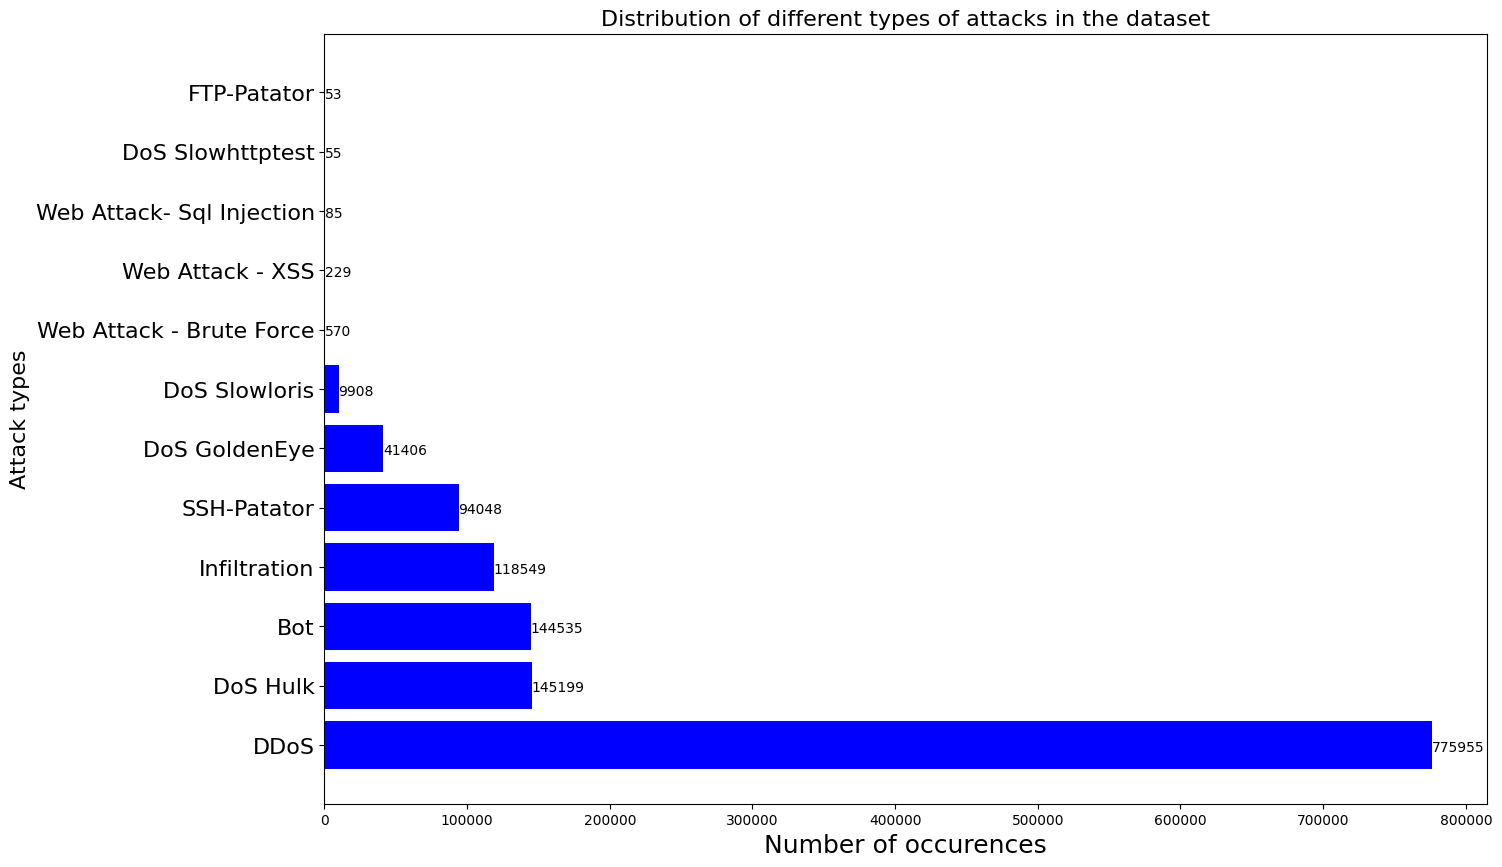

In [6]:
plt.figure(figsize=(15, 10))

attack=(
    "DDoS",
    "DoS Hulk",
    "Bot",
    "Infiltration",
    "SSH-Patator",
    "DoS GoldenEye",
    "DoS Slowloris",
    "Web Attack - Brute Force",
    "Web Attack - XSS",
    "Web Attack- Sql Injection",
    "DoS Slowhttptest",
    "FTP-Patator"
)
y_pos=np.arange(len(attack))
amount=df["Label"].value_counts()[1:]
plt.barh(y_pos, amount, align="center", color="blue")
plt.yticks(y_pos, attack, fontsize=16)
plt.title("Distribution of different types of attacks in the dataset", fontsize=16)
plt.xlabel("Number of occurences", fontsize=18)
plt.ylabel("Attack types", fontsize=16)
for i, v in enumerate(amount):
    plt.text(v+3, i-0.1, str(v))

plt.show()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11141988 entries, 0 to 11141987
Data columns (total 77 columns):
 #   Column                      Dtype 
---  ------                      ----- 
 0   Flow duration               object
 1   total Fwd packets           object
 2   total Bwd packets           object
 3   total Length of Fwd Packet  object
 4   total Length of Bwd Packet  object
 5   Fwd Packet Length Max       object
 6   Fwd Packet Length Min       object
 7   Fwd Packet Length Mean      object
 8   Fwd Packet Length Std       object
 9   Bwd Packet Length Max       object
 10  Bwd Packet Length Min       object
 11  Bwd Packet Length Mean      object
 12  Bwd Packet Length Std       object
 13  Flow Bytes/s                object
 14  Flow Packets/s              object
 15  Flow IAT Mean               object
 16  Flow IAT Std                object
 17  Flow IAT Max                object
 18  Flow IAT Min                object
 19  Fwd IAT Total               object
 20  

In [8]:
Path(output_file).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_file, index=False)